# Subperiod Analysis (Long-Short Returns)

**Date**: November 2025

## Objective

Analyze the temporal stability of the long-short annualized excess returns across three distinct market regimes:

1.  **Early (1963-1979)**
2.  **Middle (1980-1999)**
3.  **Recent (2000-2024)**

The analysis computes the annualized mean return and simple t-statistics for each subperiod, following the methodology in the double sorting analysis.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

## Configuration

In [2]:
CONFIG = {
    'start_date': '1963-07-01',
    'end_date': '2024-06-30',
    'portfolio_dir': '../data/portfolios',
    'ff_factors_file': '../data/famaFactors/FF5.csv',
    
    'subperiods': {
        'Early (1963-1979)': ('1963-07-01', '1979-12-31'),
        'Middle (1980-1999)': ('1980-01-01', '1999-12-31'),
        'Recent (2000-2024)': ('2000-01-01', '2024-06-30')
    },
    
    'use_ff6': True,
    'min_obs_subperiod': 24,
    
    'output_dir': Path('../results/latex'),
    'figures_dir': Path('../results/figures')
}

CONFIG['output_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['figures_dir'].mkdir(parents=True, exist_ok=True)

## Data Loading

In [3]:
def get_ff_factors(file_path, start_date, end_date, use_ff6=True):
    try:
        factors = pd.read_csv(file_path)
        factors['dateff'] = pd.to_datetime(factors['dateff'])
        factors = factors.set_index('dateff')
        factors.index = factors.index + pd.offsets.MonthEnd(0)
        
        # Rename columns to standard names if needed
        factors = factors.rename(columns={
            'mktrf': 'MKT',
            'smb': 'SMB',
            'hml': 'HML',
            'rmw': 'RMW',
            'cma': 'CMA',
            'rf': 'RF',
            'umd': 'MOM'
        })
        
        # Filter date range
        factors = factors[(factors.index >= pd.to_datetime(start_date)) & 
                          (factors.index <= pd.to_datetime(end_date))]
        
        # Select columns
        if use_ff6:
            cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'MOM', 'RF']
        else:
            cols = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
            
        # Check if scaling is needed (if mean > 1, assume percent)
        if factors['MKT'].abs().mean() > 1:
            print("   ℹ️  Converting % to decimals")
            factors = factors / 100.0
            
        print(f"Factors loaded: {len(factors)} observations.")
        return factors[cols]
        
    except Exception as e:
        print(f"Error loading factors: {e}")
        return None

SIGNAL_DIRECTION_MAP = {
    'debt_maturity': 'P10-P1',
    'leverage_efficiency': 'P10-P1',
    'op_margin_persist': 'P10-P1',
    'earnings_quality': 'P10-P1',
    'ebitda_margin': 'P10-P1',
    'intangible_power': 'P10-P1',
    'inv_margin': 'P10-P1',
    'receivables_turnover': 'P10-P1',
    'ppe_productivity': 'P10-P1',
    'asset_turnover_quality': 'P10-P1',
    'cash_cushion': 'P10-P1',
    'low_capex_high_margin': 'P10-P1',
    'depreciation_efficiency': 'P10-P1',
    'gp_persist': 'P10-P1',
    'asset_tangibility': 'P1-P10',
    'earnings_smoothness': 'P10-P1',
    'noa_change': 'P1-P10',
    'earnings_accel': 'P10-P1',
    'sales_accel': 'P10-P1',
    'recv_vs_sales': 'P10-P1',
    'growth_exhaustion': 'P1-P10',
    'sga_gp_leverage': 'P10-P1',
    'investment_quality': 'P10-P1',
    'roic_momentum': 'P10-P1',
    'margin_stability_new': 'P10-P1',
}

def load_portfolios(portfolio_dir, signal_map):
    portfolios = {}
    path = Path(portfolio_dir)
    
    print("Loading portfolios...")
    for file in path.glob("*.parquet"):
        signal_name = file.stem.replace('_signal', '')
        if signal_name in signal_map:
            df = pd.read_parquet(file)
            df['date'] = pd.to_datetime(df['date']) + pd.offsets.MonthEnd(0)
            df = df.set_index('date')
            portfolios[signal_name] = df
            
    print(f"Loaded {len(portfolios)} portfolios.")
    return portfolios

ff_factors = get_ff_factors(CONFIG['ff_factors_file'], CONFIG['start_date'], CONFIG['end_date'])
portfolios = load_portfolios(CONFIG['portfolio_dir'], SIGNAL_DIRECTION_MAP)

Factors loaded: 732 observations.
Loading portfolios...


Loaded 25 portfolios.


## Return Computation

In [4]:
def compute_subperiod_stats(returns, start_date, end_date):
    mask = (returns.index >= pd.to_datetime(start_date)) & (returns.index <= pd.to_datetime(end_date))
    y = returns[mask].dropna()
    
    if len(y) < CONFIG['min_obs_subperiod']:
        return np.nan, np.nan, len(y)
    
    mean_ret = y.mean()
    std_ret = y.std()
    n = len(y)
    
    if std_ret == 0:
        return np.nan, np.nan, n
        
    # Annualized Mean Return (%)
    ann_ret = mean_ret * 12 * 100
    
    # Simple T-Stat
    t_stat = (mean_ret / std_ret) * np.sqrt(n)
    
    return ann_ret, t_stat, n

def run_subperiod_analysis(portfolios, subperiods, signal_map):
    results = []
    
    for signal, df in portfolios.items():
        direction = signal_map[signal]
        
        # Standardize column names if needed
        if 'ret_low_vw' in df.columns and 'ret_high_vw' in df.columns:
            df = df.rename(columns={'ret_low_vw': 'ret_p1_vw', 'ret_high_vw': 'ret_p10_vw'})
        
        if 'ret_p10_vw' not in df.columns or 'ret_p1_vw' not in df.columns:
            continue
            
        if direction == 'P10-P1':
            ls_ret = df['ret_p10_vw'] - df['ret_p1_vw']
        else:
            ls_ret = df['ret_p1_vw'] - df['ret_p10_vw']
            
        for period_name, (start, end) in subperiods.items():
            ret, t_stat, obs = compute_subperiod_stats(
                ls_ret, start, end
            )
            
            results.append({
                'Signal': signal.replace('_', ' ').title(),
                'Period': period_name,
                'Return': ret,
                't_stat': t_stat,
                'Obs': obs
            })
            
    return pd.DataFrame(results)

# Note: Factors are not needed for simple return stats, but we keep the variable if loaded previously
df_results = run_subperiod_analysis(portfolios, CONFIG['subperiods'], SIGNAL_DIRECTION_MAP)
print(f"Computed {len(df_results)} return stats.")

Computed 75 return stats.


## Visualization 1: Dual Bar Chart

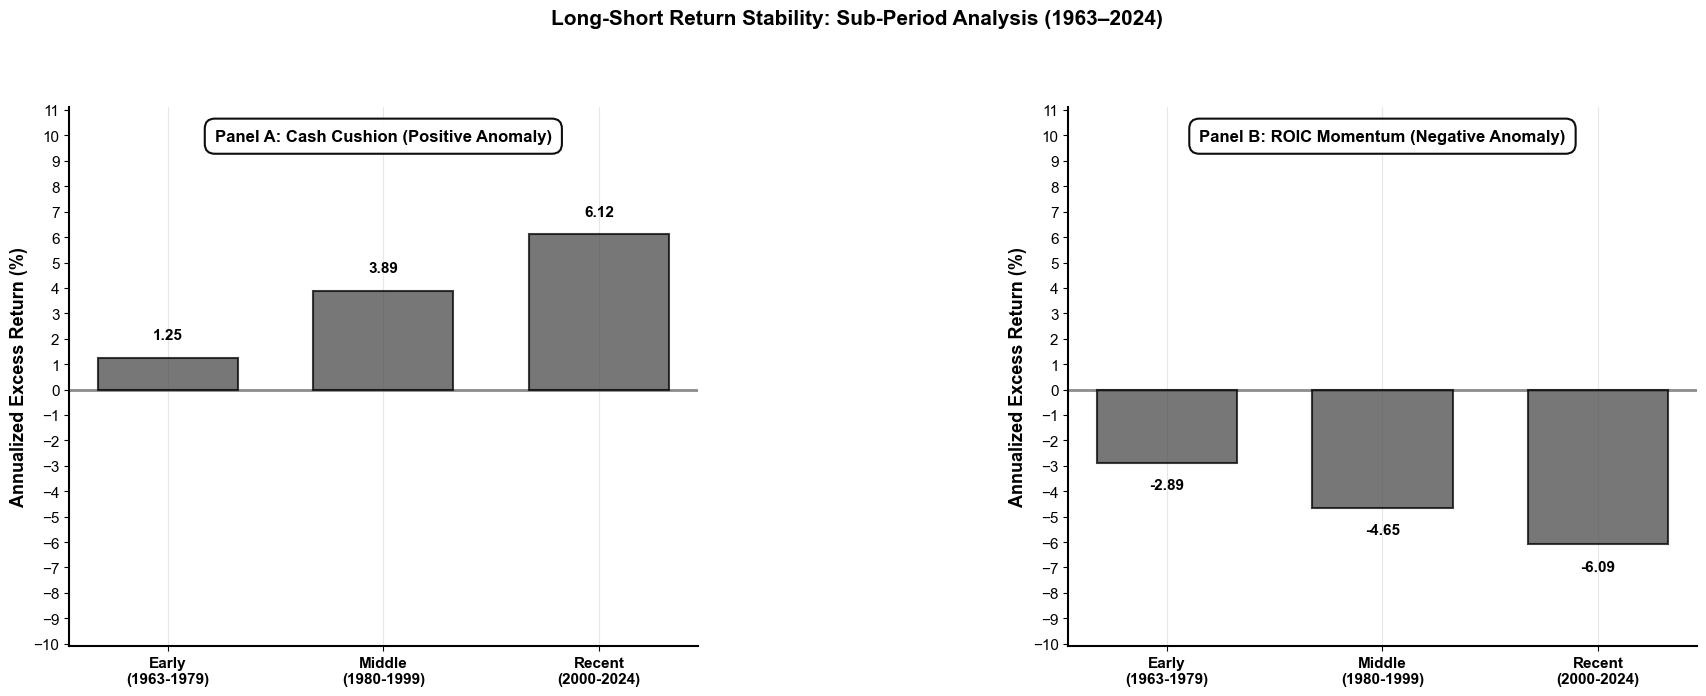

Figure saved: ../results/figures/03_2_subperiod_cash_vs_roic.png


In [5]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.6,
    'lines.linewidth': 2
})

signals_to_plot = ['Cash Cushion', 'Roic Momentum']
df_filtered = df_results[df_results['Signal'].isin(signals_to_plot)].copy()

signal_names = {
    'Cash Cushion': 'Cash Cushion',
    'Roic Momentum': 'ROIC Momentum'
}

df_filtered['Signal'] = df_filtered['Signal'].map(signal_names)

df_filtered['Period_Short'] = df_filtered['Period'].apply(lambda x: x.split(' ')[0])
period_labels = {
    'Early': 'Early\n(1963-1979)',
    'Middle': 'Middle\n(1980-1999)',
    'Recent': 'Recent\n(2000-2024)'
}

bar_color = '#4A4A4A'

fig = plt.figure(figsize=(21, 7))
gs = GridSpec(1, 2, figure=fig, wspace=0.59)

factor_label = 'FF6' if CONFIG['use_ff6'] else 'FF5'

all_rets = df_filtered['Return'].values
y_min = min(-2, all_rets.min() - 4)
y_max = max(2, all_rets.max() + 5)

# Panel A: Cash Cushion
ax1 = fig.add_subplot(gs[0, 0])
signal1 = 'Cash Cushion'
data1 = df_filtered[df_filtered['Signal'] == signal1].sort_values('Period')

x_pos = np.arange(len(data1))
bar_width = 0.65

bars1 = ax1.bar(x_pos, data1['Return'].values, 
                width=bar_width,
                color=bar_color,
                edgecolor='black',
                linewidth=1.5,
                alpha=0.75,
                zorder=3)

for i, (idx, row) in enumerate(data1.iterrows()):
    ret = row['Return']
    y_pos_value = ret + (0.6 if ret > 0 else -0.6)
    va_value = 'bottom' if ret > 0 else 'top'
    ax1.text(i, y_pos_value, f'{ret:.2f}',
             ha='center', va=va_value, fontsize=11, fontweight='bold',
             color='black')

ax1.axhline(0, color='gray', linewidth=2.0, linestyle='-', alpha=0.9, zorder=2)

ax1.set_ylabel('Annualized Excess Return (%)', fontweight='bold', fontsize=13)
ax1.set_xlabel('')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([period_labels[p] for p in data1['Period_Short']], 
                     fontsize=11, fontweight='600')

ax1.set_ylim(bottom=y_min, top=y_max)
ax1.yaxis.set_major_locator(MultipleLocator(1))

ax1.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_linewidth(1.5)

ax1.text(0.5, 0.96, 'Panel A: Cash Cushion (Positive Anomaly)',
         transform=ax1.transAxes,
         fontsize=12, fontweight='bold',
         ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                   edgecolor='black', linewidth=1.5, alpha=0.95))

# Panel B: ROIC Momentum
ax2 = fig.add_subplot(gs[0, 1])
signal2 = 'ROIC Momentum'
data2 = df_filtered[df_filtered['Signal'] == signal2].sort_values('Period')

bars2 = ax2.bar(x_pos, data2['Return'].values,
                width=bar_width,
                color=bar_color,
                edgecolor='black',
                linewidth=1.5,
                alpha=0.75,
                zorder=3)

for i, (idx, row) in enumerate(data2.iterrows()):
    ret = row['Return']
    y_pos_value = ret + (0.6 if ret > 0 else -0.6)
    va_value = 'bottom' if ret > 0 else 'top'
    ax2.text(i, y_pos_value, f'{ret:.2f}',
             ha='center', va=va_value, fontsize=11, fontweight='bold',
             color='black')

ax2.axhline(0, color='gray', linewidth=2.0, linestyle='-', alpha=0.9, zorder=2)

ax2.set_ylabel('Annualized Excess Return (%)', fontweight='bold', fontsize=13)
ax2.set_xlabel('')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([period_labels[p] for p in data2['Period_Short']], 
                     fontsize=11, fontweight='600')

ax2.set_ylim(bottom=y_min, top=y_max)
ax2.yaxis.set_major_locator(MultipleLocator(1))

ax2.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.5)
ax2.spines['bottom'].set_linewidth(1.5)

ax2.text(0.5, 0.96, 'Panel B: ROIC Momentum (Negative Anomaly)',
         transform=ax2.transAxes,
         fontsize=12, fontweight='bold',
         ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
                   edgecolor='black', linewidth=1.5, alpha=0.95))

fig.suptitle('Long-Short Return Stability: Sub-Period Analysis (1963–2024)',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])

output_path = CONFIG['figures_dir'] / '03_2_subperiod_cash_vs_roic.png'
plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')

plt.show()
print(f"Figure saved: {output_path}")

## Visualization 2: Heatmap

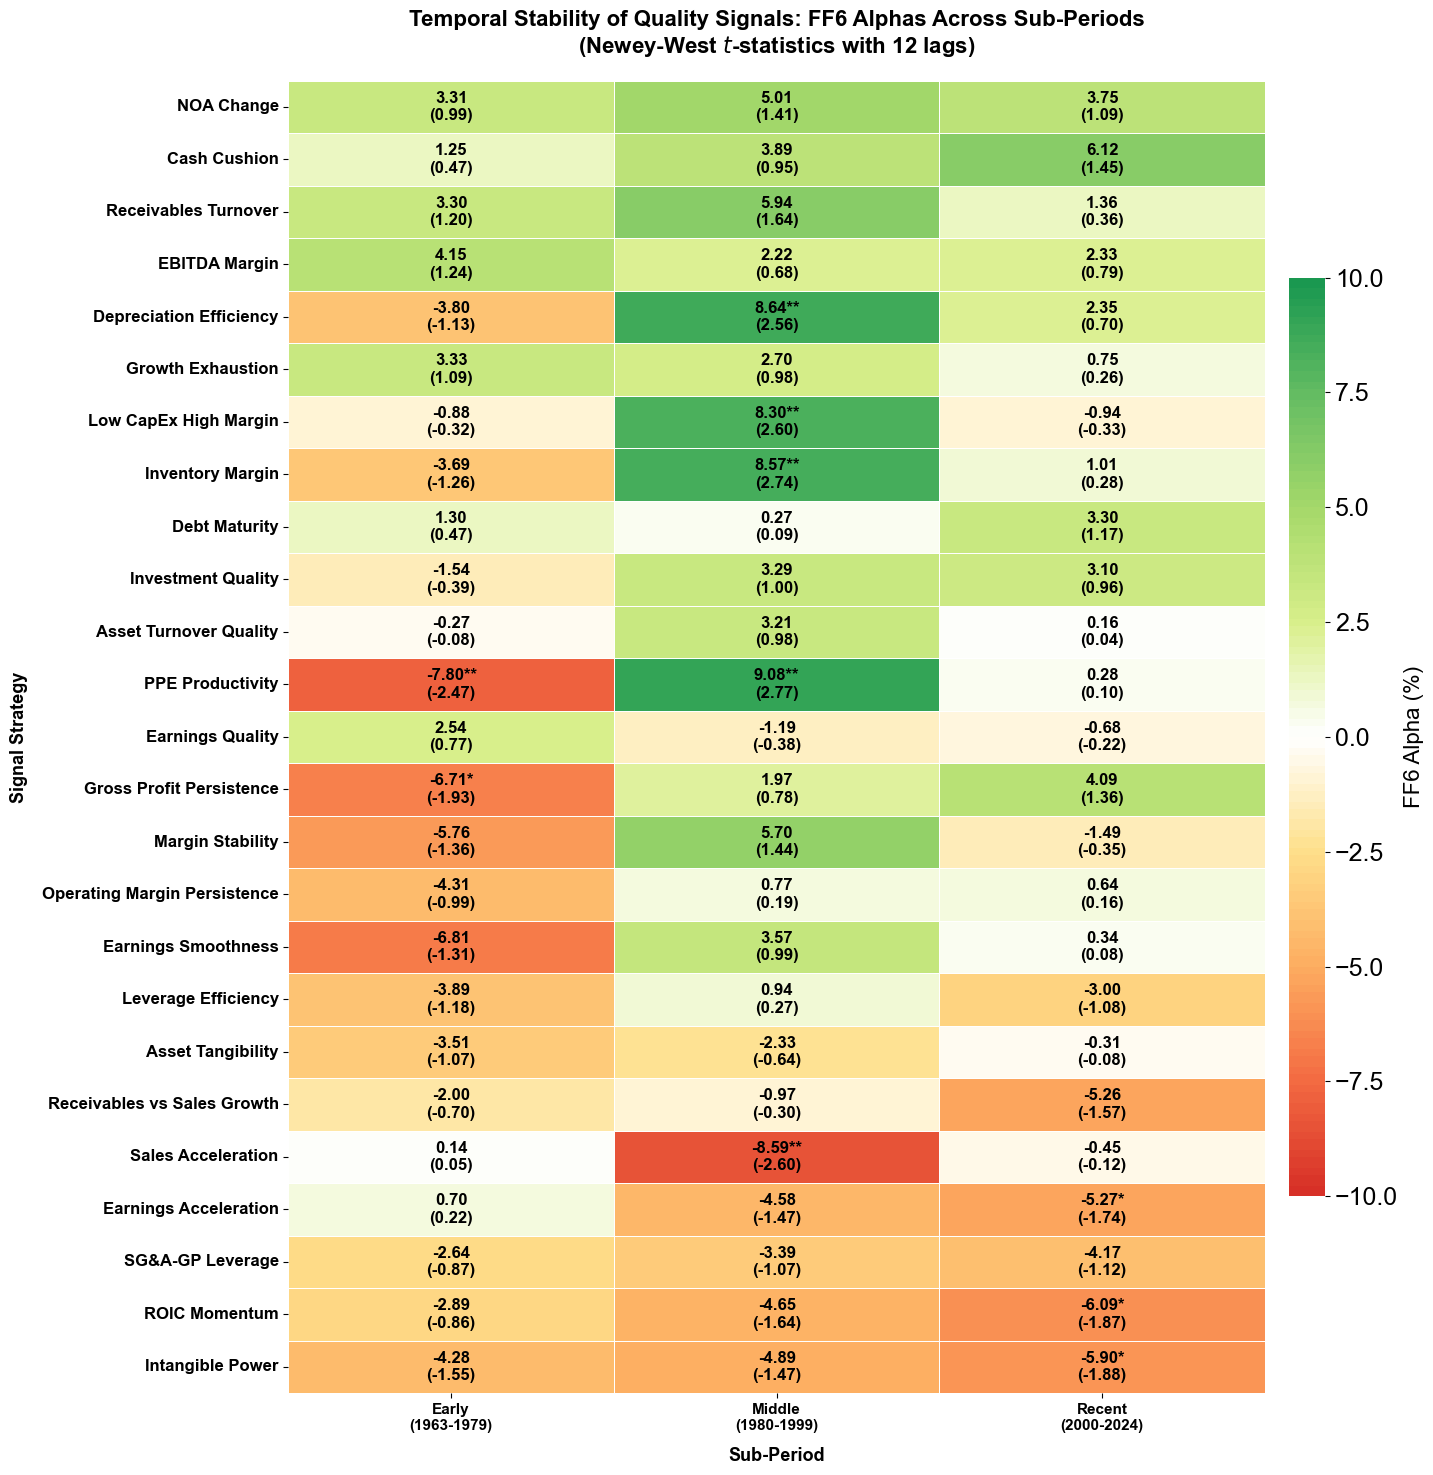

Heatmap saved: ../results/figures/Appendix_subperiod_heatmap.png


In [6]:
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 15,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 18,
})

pivot_ret = df_results.pivot(index='Signal', columns='Period', values='Return')
pivot_t = df_results.pivot(index='Signal', columns='Period', values='t_stat')

cols_order = list(CONFIG['subperiods'].keys())
heatmap_data = pivot_ret[cols_order].copy()
heatmap_tstats = pivot_t[cols_order].copy()

signal_display_names = {
    'Asset Tangibility': 'Asset Tangibility',
    'Asset Turnover Quality': 'Asset Turnover Quality',
    'Cash Cushion': 'Cash Cushion',
    'Debt Maturity': 'Debt Maturity',
    'Depreciation Efficiency': 'Depreciation Efficiency',
    'Ebitda Margin': 'EBITDA Margin',
    'Earnings Accel': 'Earnings Acceleration',
    'Earnings Quality': 'Earnings Quality',
    'Earnings Smoothness': 'Earnings Smoothness',
    'Gp Persist': 'Gross Profit Persistence',
    'Growth Exhaustion': 'Growth Exhaustion',
    'Intangible Power': 'Intangible Power',
    'Inv Margin': 'Inventory Margin',
    'Investment Quality': 'Investment Quality',
    'Leverage Efficiency': 'Leverage Efficiency',
    'Low Capex High Margin': 'Low CapEx High Margin',
    'Margin Stability New': 'Margin Stability',
    'Noa Change': 'NOA Change',
    'Op Margin Persist': 'Operating Margin Persistence',
    'Ppe Productivity': 'PPE Productivity',
    'Receivables Turnover': 'Receivables Turnover',
    'Recv Vs Sales': 'Receivables vs Sales Growth',
    'Roic Momentum': 'ROIC Momentum',
    'Sales Accel': 'Sales Acceleration',
    'Sga Gp Leverage': 'SG&A-GP Leverage'
}

heatmap_data.index = heatmap_data.index.map(lambda x: signal_display_names.get(x, x))
heatmap_tstats.index = heatmap_tstats.index.map(lambda x: signal_display_names.get(x, x))

col_labels_short = {
    'Early (1963-1979)': 'Early\n(1963-1979)',
    'Middle (1980-1999)': 'Middle\n(1980-1999)',
    'Recent (2000-2024)': 'Recent\n(2000-2024)'
}

heatmap_data.columns = [col_labels_short[col] for col in heatmap_data.columns]
heatmap_tstats.columns = [col_labels_short[col] for col in heatmap_tstats.columns]

mean_alpha = heatmap_data.mean(axis=1)
sorted_index = mean_alpha.sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[sorted_index]
heatmap_tstats = heatmap_tstats.loc[sorted_index]

def format_annotation_with_stars(alpha, tstat):
    abs_t = abs(tstat)
    if abs_t > 3.0: stars = '***'
    elif abs_t > 2.0: stars = '**'
    elif abs_t > 1.65: stars = '*'
    else: stars = ''
    
    alpha_str = f"{alpha:.2f}{stars}"
    tstat_str = f"({tstat:.2f})"
    return f"{alpha_str}\n{tstat_str}"

annot_matrix = np.empty_like(heatmap_data, dtype=object)
for i, row_idx in enumerate(heatmap_data.index):
    for j, col_idx in enumerate(heatmap_data.columns):
        alpha_val = heatmap_data.loc[row_idx, col_idx]
        tstat_val = heatmap_tstats.loc[row_idx, col_idx]
        annot_matrix[i, j] = format_annotation_with_stars(alpha_val, tstat_val)

colors = [
    '#d73027', '#f46d43', '#fdae61', '#fee08b', '#ffffff',
    '#d9ef8b', '#a6d96a', '#66bd63', '#1a9850'
]

cmap_academic = LinearSegmentedColormap.from_list('academic_saturated', colors, N=100)

n_signals = len(heatmap_data)
fig_height = max(15, n_signals * 0.50)
fig_width = 15

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

vmax_data = heatmap_data.abs().max().max()
vmax_plot = max(8, np.ceil(vmax_data / 2) * 2)
vmin_plot = -vmax_plot

sns.heatmap(heatmap_data, 
            annot=annot_matrix,
            fmt='',
            cmap=cmap_academic,
            center=0,
            vmin=vmin_plot,
            vmax=vmax_plot,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={
                'label': f'{factor_label} Alpha (%)', 
                'shrink': 0.70,
                'aspect': 25,
                'pad': 0.02
            },
            annot_kws={
                'fontsize': 12,
                'fontweight': 'bold',
                'color': 'black',
                'va': 'center'
            },
            ax=ax)

ax.set_title(f'Temporal Stability of Quality Signals: {factor_label} Alphas Across Sub-Periods\n(Newey-West $t$-statistics with 12 lags)', 
             fontsize=16, fontweight='bold', pad=20)

ax.set_xlabel('Sub-Period', fontweight='bold', fontsize=13, labelpad=10)
ax.set_ylabel('Signal Strategy', fontweight='bold', fontsize=13, labelpad=10)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=11, fontweight='600')

plt.tight_layout()

output_path = CONFIG['figures_dir'] / 'Appendix_subperiod_heatmap.png'
plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')

plt.show()
print(f"Heatmap saved: {output_path}")